In [1]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:86% !important;}
div.cell.code_cell.rendered{width:100%;}
div.CodeMirror {font-family:Consolas; font-size:15pt;}
div.output {font-size:15pt; font-weight:bold;}
div.input {font-family:Consolas; font-size:15pt;}
div.prompt {min-width:70px;}
div#toc-wrapper{padding-top:120px;}
div.text_cell_render ul li{font-size:12pt;padding:5px;}
table.dataframe{font-size:15px;}
</style>
"""))

# 1. tensorflow v2.xx에서 v1 사용하기


In [2]:
import numpy as np
import pandas as pd
import tensorflow.compat.v1 as tf
tf.disable_v2_behavior() # v2를 비활성화하고 v1 활성화

Instructions for updating:
non-resource variables are not supported in the long term


## Tensorflow
- 데이터 흐름 그래프(tensor객체의 흐름)
- 이 그래프는 node(상수, 변수, 연산)와 edge로 구성
- sess = tf.Session()으로 실행
- sess.run()을 통해 값을 확인

In [3]:
# tensor =  data(상수, 변수)와 연산
node1 = tf.constant('hello, Tensorflow')
sess = tf.Session()
print(sess.run(node1))

b'hello, Tensorflow'


In [4]:
# 간단한 연산 tensor 그래프
node1 = tf.constant(10, dtype=tf.float32)
node2 = tf.constant(20, dtype=tf.float32)
node3 = tf.add(node1,node2) 
sess = tf.Session()
print(sess.run([node1, node2, node3]))

[10.0, 20.0, 30.0]


In [5]:
# 타입변경
node1 = tf.constant(np.array([1,2,3]), dtype=tf.int16)
node2 = tf.cast(node1, dtype=tf.float32)
sess =  tf.Session()
sess.run([node1, node2])

[array([1, 2, 3], dtype=int16), array([1., 2., 3.], dtype=float32)]

In [6]:
# 평균값 계산 : tf.reduce_mean()
data = np.array([1.,2.,3.])
tensor = tf.reduce_mean(data)
sess = tf.Session()
sess.run(tensor)


2.0

In [7]:
# 랜덤값을 갖는 tensor
a = tf.random_normal([1]) # 평균 0, 표준편차가 1인 난수 실수 2개(정규분포를 이루는 난수)
sess = tf.Session()
sess.run(a)

array([-0.4255334], dtype=float32)

In [8]:
w = tf.Variable(tf.random.normal([1]))
sess = tf.Session()
sess.run(tf.global_variables_initializer()) # w변수의 난수 초기화
sess.run(w)

array([0.38207707], dtype=float32)

# 2. tensorflow v1을 이용한 linear regression을 구현
- 2.1 입력(독립)변수 x가 1개, 타겟(종속)변수 y가 1개

In [9]:
x = np.array([1,2,3])
y = np.array([2,3,4])
# weight오 bias(처음엔 랜덤값으로 셋팅, 학습과정에서 변경)
W = tf.Variable(tf.random.normal([1]), name='weight')
b = tf.Variable(tf.random.normal([1]), name='bias')
# Hypothesis : 예측값
H = W*x + b
#cost function(손실함수 = mse;최소제곱법)
cost = tf.reduce_mean(tf.square(H-y))
'''
학습목적 : cost가 최소가 되는 W, b를 찾아내는 것
cost는 2차함수이므로 곡선그래프. 곡선위 미분값이 줄어드는 방향으로 학습(경사하강)
=> GradientDescentOptimizer
'''
optimizer = tf.train.GradientDescentOptimizer(learning_rate=0.01)
train = optimizer.minimize(cost)
# Session 생성
sess = tf.Session()
# W, b 변수 노드에 초기화
sess.run(tf.global_variables_initializer())
# 5000번 학습 (v2에서는 fit함수)
for step in range(5001):
    _, cost_val, W_val, b_val = sess.run([train, cost, W, b])
    if step%200 == 0:
        print("{}번째 cost:{}, W:{}, b:{}".format(step,
                                               cost_val,
                                               W_val,
                                               b_val))

0번째 cost:6.56822395324707, W:[-0.55595547], b:[2.2010233]
200번째 cost:0.13737143576145172, W:[0.5705636], b:[1.9762099]
400번째 cost:0.05245506763458252, W:[0.73463446], b:[1.6032382]
600번째 cost:0.02002991922199726, W:[0.8360201], b:[1.3727647]
800번째 cost:0.007648433092981577, W:[0.89867026], b:[1.2303463]
1000번째 cost:0.0029205649625509977, W:[0.93738425], b:[1.1423404]
1200번째 cost:0.001115216757170856, W:[0.9613072], b:[1.0879577]
1400번째 cost:0.0004258525150362402, W:[0.9760901], b:[1.054353]
1600번째 cost:0.00016260852862615138, W:[0.98522514], b:[1.0335867]
1800번째 cost:6.208923150552437e-05, W:[0.99087024], b:[1.0207539]
2000번째 cost:2.370677248109132e-05, W:[0.99435866], b:[1.0128242]
2200번째 cost:9.052012501342688e-06, W:[0.99651396], b:[1.0079246]
2400번째 cost:3.456750164332334e-06, W:[0.9978458], b:[1.004897]
2600번째 cost:1.319812326983083e-06, W:[0.99866885], b:[1.003026]
2800번째 cost:5.043025907980336e-07, W:[0.9991772], b:[1.0018703]
3000번째 cost:1.927529780232362e-07, W:[0.9994914], b:

In [10]:
# 최종적으로 나온 회귀식 : H = W*x + b
sess.run([W, b])

[array([0.9999891], dtype=float32), array([1.0000248], dtype=float32)]

In [11]:
W_, b_ = sess.run([W, b])
W_[0], b_[0]

(0.9999891, 1.0000248)

In [12]:
def predict(x):
    return W_[0]*x + b_[0]

In [13]:
input_x = int(input('입력값은 ?'))
print('예측값은 ', predict(input_x))

입력값은 ?7
예측값은  7.999948441982269


## 2.2 predict를 위한 placeholder이용
- placeholder : 텐서플로우 외부에서 데이터를 입력받는 노드


In [14]:
# x = np.array([1,2,3])
x = tf.placeholder(tf.float16)
H = 1*x + 1
sess = tf.Session()
sess.run(H, feed_dict={x:5})
sess.run(H, feed_dict={x:np.array([1,2,3])})

array([2., 3., 4.], dtype=float16)

In [15]:
# H = 2x+1
x_data = np.array([1,2,3,5,8])
y_data = np.array([3,5,7,11,17])
# placeholder 설정 (입력변수 x, 타겟변수 y)
x = tf.placeholder(dtype=tf.float32)
y = tf.placeholder(dtype=tf.float32)
# W, b
W = tf.Variable(tf.random.normal([1]))
b = tf.Variable(tf.random.normal([1]))
# Hypothesis(예측값)
H = W*x + b
# 손실함수
cost = tf.reduce_mean(tf.square(H-y))
# 경사하강법
train = tf.train.GradientDescentOptimizer(learning_rate=0.01).minimize(cost)
# Session 객체 생성
sess = tf.Session()
sess.run(tf.global_variables_initializer()) # W, b 초기화
# 5000번 학습
for step in range(5001):
    _, cost_val, W_val, b_val = sess.run([train, cost, W, b], 
                                         feed_dict={x:x_data,
                                                   y:y_data})
    if step%200 == 0:
        print('{}째 : cost:{}, W:{}, b:{}'.format(step, cost_val, W_val, b_val))

0째 : cost:159.4451446533203, W:[0.37925005], b:[1.1300051]
200째 : cost:0.005215880461037159, W:[1.9754394], b:[1.1312761]
400째 : cost:0.0005130235804244876, W:[1.9922972], b:[1.0411712]
600째 : cost:5.046130536356941e-05, W:[1.9975842], b:[1.0129123]
800째 : cost:4.962240382155869e-06, W:[1.9992423], b:[1.0040493]
1000째 : cost:4.884503823632258e-07, W:[1.9997624], b:[1.0012702]
1200째 : cost:4.80204676023277e-08, W:[1.9999254], b:[1.0003986]
1400째 : cost:4.746254944620887e-09, W:[1.9999765], b:[1.0001252]
1600째 : cost:4.851699597629988e-10, W:[1.9999926], b:[1.0000397]
1800째 : cost:3.951754548592312e-11, W:[1.9999977], b:[1.0000116]
2000째 : cost:3.470859016863059e-11, W:[1.9999979], b:[1.000011]
2200째 : cost:3.470859016863059e-11, W:[1.9999979], b:[1.000011]
2400째 : cost:3.470859016863059e-11, W:[1.9999979], b:[1.000011]
2600째 : cost:3.470859016863059e-11, W:[1.9999979], b:[1.000011]
2800째 : cost:3.470859016863059e-11, W:[1.9999979], b:[1.000011]
3000째 : cost:3.470859016863059e-11, W:[1.9

In [16]:
# 예측하기
sess.run(H, feed_dict={x:5})


array([11.], dtype=float32)

In [17]:
sess.run(H, feed_dict={x:np.array([5, 6, 7])})

array([11.      , 12.999998, 14.999996], dtype=float32)

# 2.3 scale이 다른 데이터의 linear regression 구현(scale조정X)

In [18]:
x_data = np.array([1,2,5,8,10])
y_data = np.array([3,15,68,80,95])
# placeholder 설정 (입력변수 x, 타겟변수 y)
x = tf.placeholder(dtype=tf.float32)
y = tf.placeholder(dtype=tf.float32)
# W, b
W = tf.Variable(tf.random.normal([1]))
b = tf.Variable(tf.random.normal([1]))
# Hypothesis(예측값)
H = W*x + b
# 손실함수
cost = tf.reduce_mean(tf.square(H-y))
# 경사하강법
train = tf.train.GradientDescentOptimizer(learning_rate=0.01).minimize(cost)
# Session 객체 생성
sess = tf.Session()
sess.run(tf.global_variables_initializer()) # W, b 초기화
# 3000번 학습
for step in range(3001):
    _, cost_val, W_val, b_val = sess.run([train, cost, W, b], 
                                         feed_dict={x:x_data,
                                                   y:y_data})
    if step%200 == 0:
        print('{}째 : cost:{}, W:{}, b:{}'.format(step, cost_val, W_val, b_val))

0째 : cost:4482.0205078125, W:[7.8021216], b:[0.5909932]
200째 : cost:83.62627410888672, W:[10.210204], b:[-0.68912286]
400째 : cost:83.49554443359375, W:[10.274698], b:[-1.166659]
600째 : cost:83.48350524902344, W:[10.294233], b:[-1.311302]
800째 : cost:83.48243713378906, W:[10.30015], b:[-1.3551133]
1000째 : cost:83.48233795166016, W:[10.301943], b:[-1.3683845]
1200째 : cost:83.48231506347656, W:[10.302485], b:[-1.372403]
1400째 : cost:83.48231506347656, W:[10.3026495], b:[-1.3736203]
1600째 : cost:83.4823226928711, W:[10.302699], b:[-1.3739886]
1800째 : cost:83.48231506347656, W:[10.302714], b:[-1.3740997]
2000째 : cost:83.48230743408203, W:[10.302718], b:[-1.3741322]
2200째 : cost:83.48233032226562, W:[10.302718], b:[-1.3741326]
2400째 : cost:83.48233032226562, W:[10.302718], b:[-1.3741326]
2600째 : cost:83.48233032226562, W:[10.302718], b:[-1.3741326]
2800째 : cost:83.48233032226562, W:[10.302718], b:[-1.3741326]
3000째 : cost:83.48233032226562, W:[10.302718], b:[-1.3741326]


In [19]:
# cost값이 멈춤 : local 최소값

# 2.4 scale이 다른 데이터의 linear regression을 구현(조정O)
## scale을 맞추기 : 모든 데이터를 일정 범위내로 조정
- normalization(정규화) : 0~1로 조정 
                       X - Xmin 
     normalization = ──────────── 
                     Xmax - Xmin 
 * 위의 식을 써도 되지만 라이브러리를 씀   (sklearn.preprocessing.MinMaxScaler이용)

- standardization(표준화) : 평균0, 표준편차1로 조정 
                    X - Xmean(평균) 
  standardization = ────────────────── 
                      Xstd(표준편차) 
 * 위의 식을 써도 되지만 라이브러리를 씀(sklearn.preprocessing.StandardScaler이용)

In [20]:
# 라이브러리를 쓰지 않고 정규화
x_data = np.array([1,2,5,8,10])
y_data = np.array([3,15,68,80,95])
scaled_x_data = (x_data - x_data.min() ) / (x_data.max() - x_data.min())
scaled_y_data = (y_data - y_data.min() ) / (y_data.max() - y_data.min())
print(scaled_x_data)
print(scaled_y_data)


[0.         0.11111111 0.44444444 0.77777778 1.        ]
[0.         0.13043478 0.70652174 0.83695652 1.        ]


In [30]:
# 라이브러리를 쓰고 정규화 (MinMaxScaler이용)
x_data = np.array([1,2,5,8,10]).reshape(-1, 1)
y_data = np.array([3,15,68,80,95]).reshape(-1,1)
# np.column_stack([x_data, y_data])
from sklearn.preprocessing import MinMaxScaler
scaler_x = MinMaxScaler() # x_data를 정규화시킬 객체
# scaler_x.fit(x_data)
# scaled_x_data = scaler_x.transform(x_data)
scaled_x_data = scaler_x.fit_transform(x_data)
scaler_y = MinMaxScaler() # y_data를 정규화시킬 객체
scaled_y_data = scaler_y.fit_transform(y_data)
np.column_stack([x_data, y_data, scaled_x_data, scaled_y_data])

array([[ 1.        ,  3.        ,  0.        ,  0.        ],
       [ 2.        , 15.        ,  0.11111111,  0.13043478],
       [ 5.        , 68.        ,  0.44444444,  0.70652174],
       [ 8.        , 80.        ,  0.77777778,  0.83695652],
       [10.        , 95.        ,  1.        ,  1.        ]])

In [31]:
# placeholder 설정 (입력변수 x, 타겟변수 y)
x = tf.placeholder(dtype=tf.float32)
y = tf.placeholder(dtype=tf.float32)
# W, b
W = tf.Variable(tf.random.normal([1]))
b = tf.Variable(tf.random.normal([1]))
# Hypothesis(예측값)
H = W*x + b
# 손실함수
cost = tf.reduce_mean(tf.square(H-y))
# 경사하강법
train = tf.train.GradientDescentOptimizer(learning_rate=0.001).minimize(cost)
# Session 객체 생성
sess = tf.Session()
sess.run(tf.global_variables_initializer()) # W, b 초기화
# 12000번 학습
for step in range(12001):
    _, cost_val, W_val, b_val = sess.run([train, cost, W, b], 
                                         feed_dict={x:scaled_x_data,
                                                   y:scaled_y_data})
    if step%600 == 0:
        print('{}째 : cost:{}, W:{}, b:{}'.format(step, cost_val, W_val, b_val))

0째 : cost:1.7315460443496704, W:[-0.97177833], b:[-0.08205386]
600째 : cost:0.32878056168556213, W:[-0.3955376], b:[0.53908217]
1200째 : cost:0.20183464884757996, W:[-0.14133526], b:[0.61180794]
1800째 : cost:0.15255479514598846, W:[0.02449237], b:[0.5705149]
2400째 : cost:0.11763016134500504, W:[0.15633829], b:[0.51122916]
3000째 : cost:0.09134030342102051, W:[0.26822224], b:[0.45444906]
3600째 : cost:0.07146824896335602, W:[0.3648926], b:[0.40390703]
4200째 : cost:0.056443143635988235, W:[0.44881353], b:[0.35969687]
4800째 : cost:0.04508262127637863, W:[0.5217553], b:[0.32119587]
5400째 : cost:0.036492832005023956, W:[0.5851746], b:[0.2877044]
6000째 : cost:0.02999802865087986, W:[0.6403191], b:[0.2585791]
6600째 : cost:0.025087248533964157, W:[0.68826944], b:[0.2332526]
7200째 : cost:0.021374212577939034, W:[0.72996384], b:[0.21123013]
7800째 : cost:0.018566742539405823, W:[0.7662194], b:[0.19208057]
8400째 : cost:0.016444014385342598, W:[0.7977447], b:[0.17542912]
9000째 : cost:0.0148390037938952

In [35]:
# 예측 : 모델에 scale 조정된 값으로 예측=>scale 조정된 y값
scaled_input = scaler_x.transform(np.array([[2],
                                            [3]]))
print('모델 예측을 위한 입력 :', scaled_input, sep='\n')
scaled_output = sess.run(H, feed_dict={x:scaled_input})
print('모델 예측 결과 :', scaled_output, sep='\n')
print('결과 :', scaler_y.inverse_transform(scaled_output), sep='\n')

모델 예측을 위한 입력 :
[[0.11111111]
 [0.22222222]]
모델 예측 결과 :
[[0.21431094]
 [0.31620458]]
결과 :
[[22.716608]
 [32.09082 ]]


In [36]:
# x_data들의 예측값
scaled_y_hat = sess.run(H, feed_dict={x:scaled_x_data})
y_hat = scaler_y.inverse_transform(scaled_y_hat)

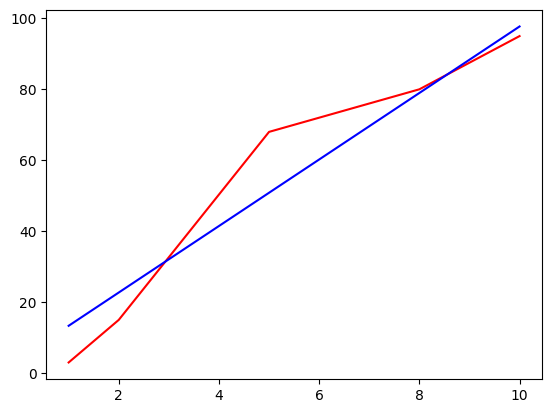

In [37]:
import matplotlib.pyplot as plt
plt.plot(x_data, y_data, 'r')
plt.plot(x_data, y_hat, 'b')

In [41]:
# 라이브러리를 쓰고 표준화(StandardScaler 이용)
x_data = np.array([1,2,5,8,10]).reshape(-1, 1)
y_data = np.array([3,15,68,80,95]).reshape(-1,1)
from sklearn.preprocessing import StandardScaler
scaler_x = StandardScaler() # x_data를 표준화할 객체
scaler_y = StandardScaler() # y_data를 표준화할 객체
scaled_x_data = scaler_x.fit_transform(x_data)
scaled_y_data = scaler_y.fit_transform(y_data)
print(np.column_stack([x_data, y_data]))
print(np.column_stack([scaled_x_data, scaled_y_data]))

[[ 1  3]
 [ 2 15]
 [ 5 68]
 [ 8 80]
 [10 95]]
[[-1.22474487 -1.34819316]
 [-0.93313895 -1.01936556]
 [-0.05832118  0.43295634]
 [ 0.81649658  0.76178394]
 [ 1.39970842  1.17281844]]


In [42]:
# placeholder 설정 (입력변수 x, 타겟변수 y)
x = tf.placeholder(dtype=tf.float32)
y = tf.placeholder(dtype=tf.float32)
# W, b
W = tf.Variable(tf.random.normal([1]))
b = tf.Variable(tf.random.normal([1]))
# Hypothesis(예측값)
H = W*x + b
# 손실함수
cost = tf.reduce_mean(tf.square(H-y))
# 경사하강법
train = tf.train.GradientDescentOptimizer(learning_rate=0.001).minimize(cost)
# Session 객체 생성
sess = tf.Session()
sess.run(tf.global_variables_initializer()) # W, b 초기화
# 12000번 학습
for step in range(12001):
    _, cost_val, W_val, b_val = sess.run([train, cost, W, b], 
                                         feed_dict={x:scaled_x_data,
                                                   y:scaled_y_data})
    if step%600 == 0:
        print('{}째 : cost:{}, W:{}, b:{}'.format(step, cost_val, W_val, b_val))

0째 : cost:0.49792322516441345, W:[0.5200899], b:[0.48243186]
600째 : cost:0.10207480192184448, W:[0.8333589], b:[0.14513128]
1200째 : cost:0.06625042855739594, W:[0.92760056], b:[0.04366023]
1800째 : cost:0.06300830841064453, W:[0.95595104], b:[0.01313442]
2400째 : cost:0.06271489709615707, W:[0.9644802], b:[0.00395127]
3000째 : cost:0.06268833577632904, W:[0.96704584], b:[0.00118868]
3600째 : cost:0.06268594413995743, W:[0.96781766], b:[0.0003576]
4200째 : cost:0.06268571317195892, W:[0.96804976], b:[0.00010759]
4800째 : cost:0.06268569827079773, W:[0.9681176], b:[3.2375126e-05]
5400째 : cost:0.06268569082021713, W:[0.96813506], b:[9.755332e-06]
6000째 : cost:0.06268569082021713, W:[0.96813506], b:[2.9533558e-06]
6600째 : cost:0.06268570572137833, W:[0.96813506], b:[9.071384e-07]
7200째 : cost:0.06268569082021713, W:[0.96813506], b:[2.912889e-07]
7800째 : cost:0.06268569082021713, W:[0.96813506], b:[1.09293055e-07]
8400째 : cost:0.06268568336963654, W:[0.96813506], b:[5.578311e-08]
9000째 : cost:0.0

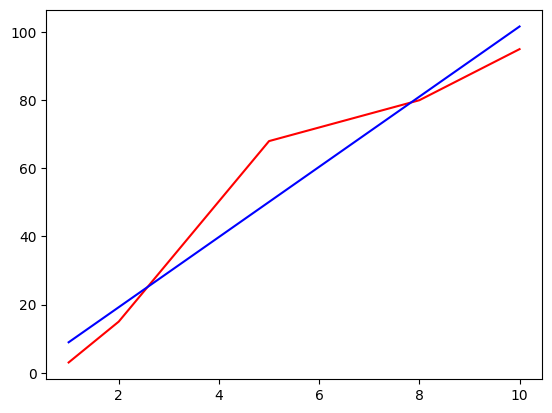

In [43]:
# x_data들의 예측값
scaled_y_hat = sess.run(H, feed_dict={x:scaled_x_data})
y_hat = scaler_y.inverse_transform(scaled_y_hat)
import matplotlib.pyplot as plt
plt.plot(x_data, y_data, 'r')
plt.plot(x_data, y_hat, 'b')